# 04 — ML Model Training & Evaluation
**Project:** A Data-Driven Predictive Control Framework for HVAC Cooling Optimisation
**Author:** Cheuk Fung Donald Man | Imperial College London | MEng Civil Engineering

---
Trains and compares three supervised ML models for predicting total HVAC electricity demand (`hvac_kwh`).

**Sections:**
1. Imports & constants
2. Load data & prepare feature matrices
3. Evaluation helper
4. Persistence baseline
5. Random Forest
6. XGBoost
7. LSTM
8. Model comparison
9. Actual vs predicted scatter (best model)
10. Per-climate error breakdown
11. Save results & best model reference
12. Summary

**Inputs:** `data/processed/features_{train,val,test}.parquet`, `scaler_X.pkl`, `scaler_y.pkl`, `feature_sets.json`

**Outputs:** `model_rf.pkl`, `model_xgb.pkl`, `model_lstm/`, `model_results.json`, 6 figures

## 1. Imports & Constants

In [1]:
import json
import joblib
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import tensorflow as tf
import keras
from keras.models    import Sequential
from keras.layers    import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ── Paths ──────────────────────────────────────────────────────────
DATA_IN  = Path('../data/processed')
DATA_OUT = Path('../data/processed')
FIG_OUT  = Path('../figures')
FIG_OUT.mkdir(parents=True, exist_ok=True)

# ── Constants ──────────────────────────────────────────────────────
RANDOM_STATE = 42
LOOKBACK     = 24        # LSTM sequence length: 24 × 10-min steps = 4 hours
TARGET       = 'hvac_kwh'

CLIMATE_COLOURS = {'1A': '#E24B4A', '3C': '#2E75B6', '5A': '#639922'}
CLIMATE_LABELS  = {'1A': 'Miami (1A)', '3C': 'San Francisco (3C)', '5A': 'Chicago (5A)'}

# ── Plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'sans-serif', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

print(f'TensorFlow {tf.__version__}  |  Keras {keras.__version__}  |  XGBoost {xgb.__version__}')

TensorFlow 2.16.2  |  Keras 3.10.0  |  XGBoost 2.1.4


## 2. Load Data & Prepare Feature Matrices

In [2]:
# ── Load feature sets metadata ─────────────────────────────────────
with open(DATA_IN / 'feature_sets.json') as f:
    fs = json.load(f)

FULL_FEATURES = fs['FULL_FEATURES']   # 31 features
TARGET        = fs['TARGET']          # 'hvac_kwh'

print(f'FULL_FEATURES : {len(FULL_FEATURES)} features')
print(f'TARGET        : {TARGET}')

# ── Load scalers ───────────────────────────────────────────────────
scaler_X = joblib.load(DATA_IN / 'scaler_X.pkl')
scaler_y = joblib.load(DATA_IN / 'scaler_y.pkl')

print(f'\nscaler_y: mean={scaler_y.mean_[0]:.4f} kWh, scale={scaler_y.scale_[0]:.4f} kWh')

# ── Load parquets ──────────────────────────────────────────────────
df_train = pd.read_parquet(DATA_IN / 'features_train.parquet')
df_val   = pd.read_parquet(DATA_IN / 'features_val.parquet')
df_test  = pd.read_parquet(DATA_IN / 'features_test.parquet')

print(f'\nTrain : {len(df_train):,} rows  |  Val : {len(df_val):,} rows  |  Test : {len(df_test):,} rows')
print(f'Columns ({df_train.shape[1]}): {list(df_train.columns)}')

# ── Build feature matrices ─────────────────────────────────────────
X_train = df_train[FULL_FEATURES].values
y_train = df_train[TARGET].values

X_val   = df_val[FULL_FEATURES].values
y_val   = df_val[TARGET].values

X_test  = df_test[FULL_FEATURES].values
y_test  = df_test[TARGET].values

# ── Reconstruct climate labels from OHE (for per-climate eval) ─────
def get_climate(df):
    return np.where(df['climate_1A'] == 1, '1A',
           np.where(df['climate_3C'] == 1, '3C', '5A'))

climate_test = get_climate(df_test)

print(f'\nX_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}    |  y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'Test climate breakdown: { {z: (climate_test==z).sum() for z in ["1A","3C","5A"]} }')

FULL_FEATURES : 31 features
TARGET        : hvac_kwh

scaler_y: mean=3.7189 kWh, scale=3.9092 kWh

Train : 110,073 rows  |  Val : 23,586 rows  |  Test : 23,589 rows
Columns (32): ['hvac_kwh', 'lighting_kwh', 'plugloads_kwh', 'oat_c', 'wetbulb_c', 'occupancy', 'indoor_temp_c', 'hour', 'dayofweek', 'month', 'is_weekday', 'is_occupied', 'oat_roll1h', 'oat_roll3h', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'hvac_lag1', 'hvac_lag6', 'hvac_lag144', 'hvac_roll1h', 'hvac_roll24h', 'oat_dev', 'wetbulb_dev', 'indoor_dev', 'oat_sq', 'climate_1A', 'climate_3C', 'climate_5A']

X_train : (110073, 31)  |  y_train : (110073,)
X_val   : (23586, 31)    |  y_val   : (23586,)
X_test  : (23589, 31)   |  y_test  : (23589,)
Test climate breakdown: {'1A': 7863, '3C': 7863, '5A': 7863}


## 3. Evaluation Helper

All metrics are reported in **kWh** (inverse-transformed from scaled space).  
Val set is used for model selection; test set is the held-out final evaluation.

In [3]:
def inv(y_scaled):
    """Inverse-transform a 1-D scaled array back to kWh."""
    return scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

def evaluate(y_true_s, y_pred_s, label=''):
    """Compute RMSE / MAE / R² in kWh and return as dict."""
    y_true = inv(y_true_s)
    y_pred = inv(y_pred_s)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    if label:
        print(f'{label:<22s}  RMSE={rmse:.4f} kWh   MAE={mae:.4f} kWh   R²={r2:.4f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2,
            'y_true_kwh': y_true, 'y_pred_kwh': y_pred}

def evaluate_per_climate(y_true_s, y_pred_s, climate_arr, label=''):
    """Break down RMSE/MAE/R² by climate zone."""
    results = {}
    y_true = inv(y_true_s)
    y_pred = inv(y_pred_s)
    for zone in ['1A', '3C', '5A']:
        mask = climate_arr == zone
        rmse = float(np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])))
        mae  = float(mean_absolute_error(y_true[mask], y_pred[mask]))
        r2   = float(r2_score(y_true[mask], y_pred[mask]))
        results[zone] = {'rmse': rmse, 'mae': mae, 'r2': r2}
        print(f'  {label} | Zone {zone}: RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return results

print('Evaluation helpers defined.')

Evaluation helpers defined.


## 4. Persistence Baseline

Predicts `ŷ(t) = hvac_kwh(t-1)` — the simplest possible forecast.  
Any trained model must meaningfully outperform this floor.  
`hvac_lag1` is already in the feature matrix so we can read it directly.

In [4]:
lag1_idx = FULL_FEATURES.index('hvac_lag1')

# Val baseline: predict y_val using lag1 column from X_val
val_lag1_pred  = X_val[:, lag1_idx]
test_lag1_pred = X_test[:, lag1_idx]

print('── Persistence Baseline (ŷ = lag1) ──')
baseline_val  = evaluate(y_val,  val_lag1_pred,  label='Baseline  [val ]')
baseline_test = evaluate(y_test, test_lag1_pred, label='Baseline  [test]')

all_results = {
    'baseline': {
        'val' : {k: v for k, v in baseline_val.items()  if k != 'y_true_kwh' and k != 'y_pred_kwh'},
        'test': {k: v for k, v in baseline_test.items() if k != 'y_true_kwh' and k != 'y_pred_kwh'},
    }
}

── Persistence Baseline (ŷ = lag1) ──
Baseline  [val ]        RMSE=1.3650 kWh   MAE=0.5358 kWh   R²=0.8431
Baseline  [test]        RMSE=1.3572 kWh   MAE=0.4190 kWh   R²=0.8680


## 5. Random Forest

`RandomForestRegressor` is scale-invariant so it trains directly on the scaled feature matrix.  
500 trees with no depth limit — a strong out-of-the-box baseline for tabular HVAC data.

In [5]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Training Random Forest (500 trees) ...')
rf.fit(X_train, y_train)
print('Done.')

rf_val_pred  = rf.predict(X_val)
rf_test_pred = rf.predict(X_test)

print('\n── Random Forest ──')
rf_val_res  = evaluate(y_val,  rf_val_pred,  label='RF        [val ]')
rf_test_res = evaluate(y_test, rf_test_pred, label='RF        [test]')

all_results['rf'] = {
    'val' : {k: v for k, v in rf_val_res.items()  if not k.startswith('y_')},
    'test': {k: v for k, v in rf_test_res.items() if not k.startswith('y_')},
}

# Save model
joblib.dump(rf, DATA_OUT / 'model_rf.pkl')
print(f'\nSaved: model_rf.pkl')

Training Random Forest (500 trees) ...
Done.

── Random Forest ──
RF        [val ]        RMSE=0.2249 kWh   MAE=0.0916 kWh   R²=0.9957
RF        [test]        RMSE=0.3445 kWh   MAE=0.1250 kWh   R²=0.9915

Saved: model_rf.pkl


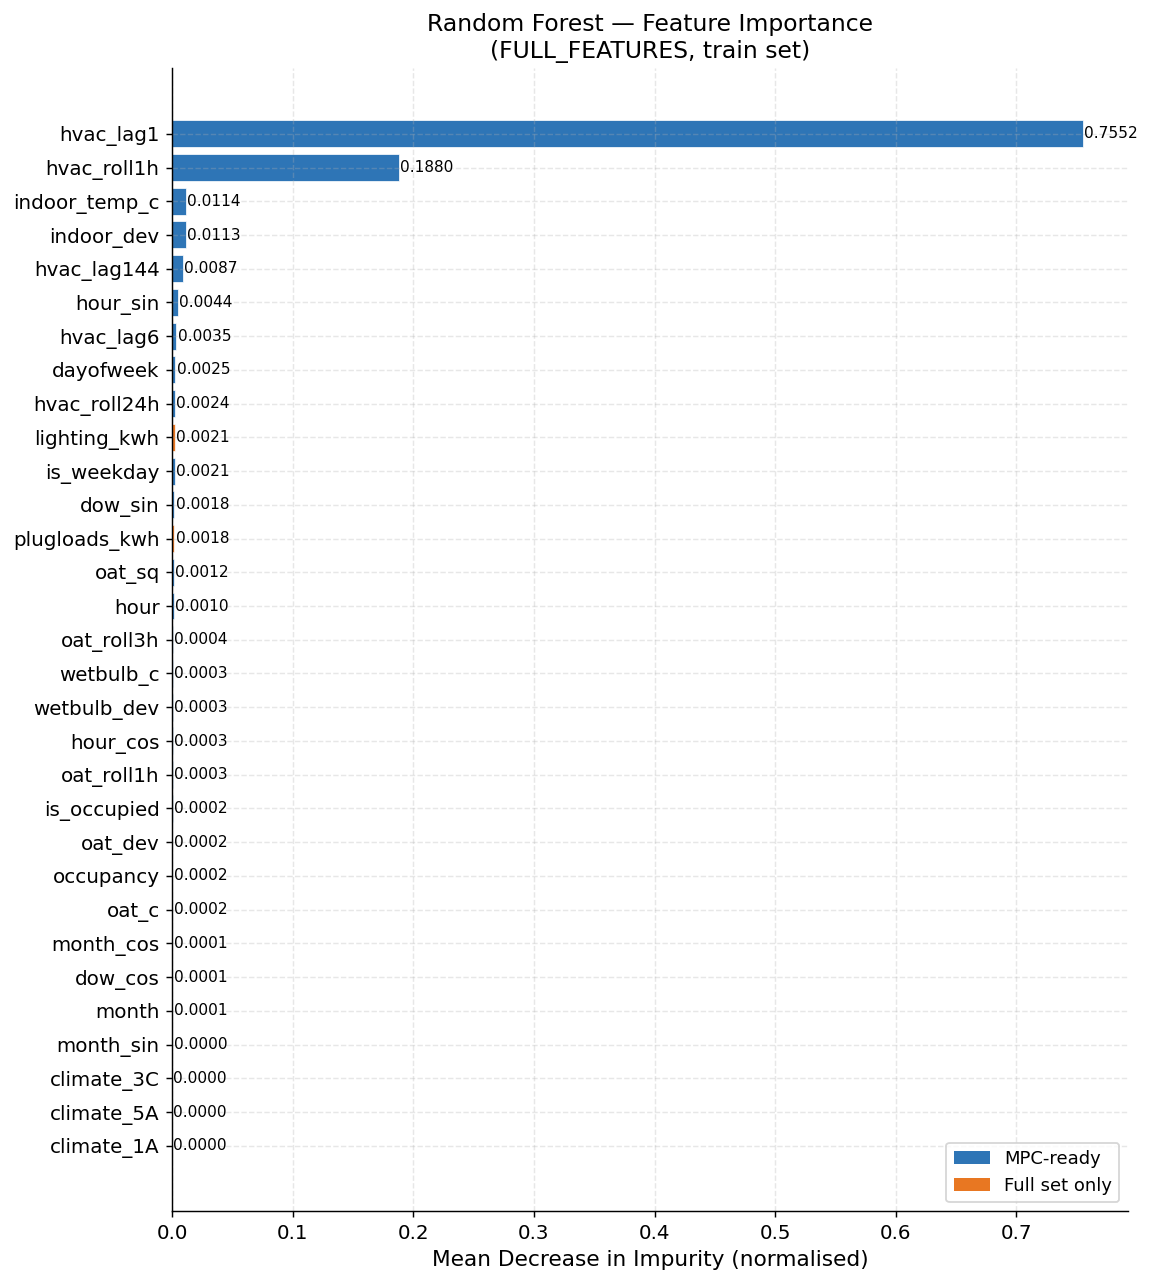

Saved: figures/04_feature_importance_rf.png


In [6]:
# RF feature importance
importances = pd.Series(rf.feature_importances_, index=FULL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 10))
colours = ['#E87722' if f in ('lighting_kwh', 'plugloads_kwh') else '#2E75B6'
           for f in importances.index]
bars = ax.barh(importances.index, importances.values, color=colours,
               edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Mean Decrease in Impurity (normalised)', fontsize=12)
ax.set_title('Random Forest — Feature Importance\n(FULL_FEATURES, train set)', fontsize=13)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#2E75B6', label='MPC-ready'),
                   Patch(facecolor='#E87722', label='Full set only')],
          loc='lower right', fontsize=10)

plt.tight_layout()
fig.savefig(FIG_OUT / '04_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_feature_importance_rf.png')

## 6. XGBoost

Gradient boosting with early stopping on the validation set.  
1000 max trees, learning rate 0.05 — early stopping finds the optimal tree count automatically.

In [7]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    device='cpu',
    verbosity=0,
)

print('Training XGBoost (up to 1000 trees, early stopping) ...')
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100,
)
print(f'Best iteration: {xgb_model.best_iteration}')

xgb_val_pred  = xgb_model.predict(X_val)
xgb_test_pred = xgb_model.predict(X_test)

print('\n── XGBoost ──')
xgb_val_res  = evaluate(y_val,  xgb_val_pred,  label='XGBoost   [val ]')
xgb_test_res = evaluate(y_test, xgb_test_pred, label='XGBoost   [test]')

all_results['xgb'] = {
    'val' : {k: v for k, v in xgb_val_res.items()  if not k.startswith('y_')},
    'test': {k: v for k, v in xgb_test_res.items() if not k.startswith('y_')},
    'best_iteration': int(xgb_model.best_iteration),
}

joblib.dump(xgb_model, DATA_OUT / 'model_xgb.pkl')
print(f'\nSaved: model_xgb.pkl')

Training XGBoost (up to 1000 trees, early stopping) ...
[0]	validation_0-rmse:0.84009
[100]	validation_0-rmse:0.08201
[200]	validation_0-rmse:0.07093
[300]	validation_0-rmse:0.06644
[400]	validation_0-rmse:0.06390
[500]	validation_0-rmse:0.06273
[600]	validation_0-rmse:0.06155
[700]	validation_0-rmse:0.06083
[800]	validation_0-rmse:0.05998
[900]	validation_0-rmse:0.05928
[999]	validation_0-rmse:0.05879
Best iteration: 999

── XGBoost ──
XGBoost   [val ]        RMSE=0.2298 kWh   MAE=0.1217 kWh   R²=0.9956
XGBoost   [test]        RMSE=0.3401 kWh   MAE=0.1885 kWh   R²=0.9917

Saved: model_xgb.pkl


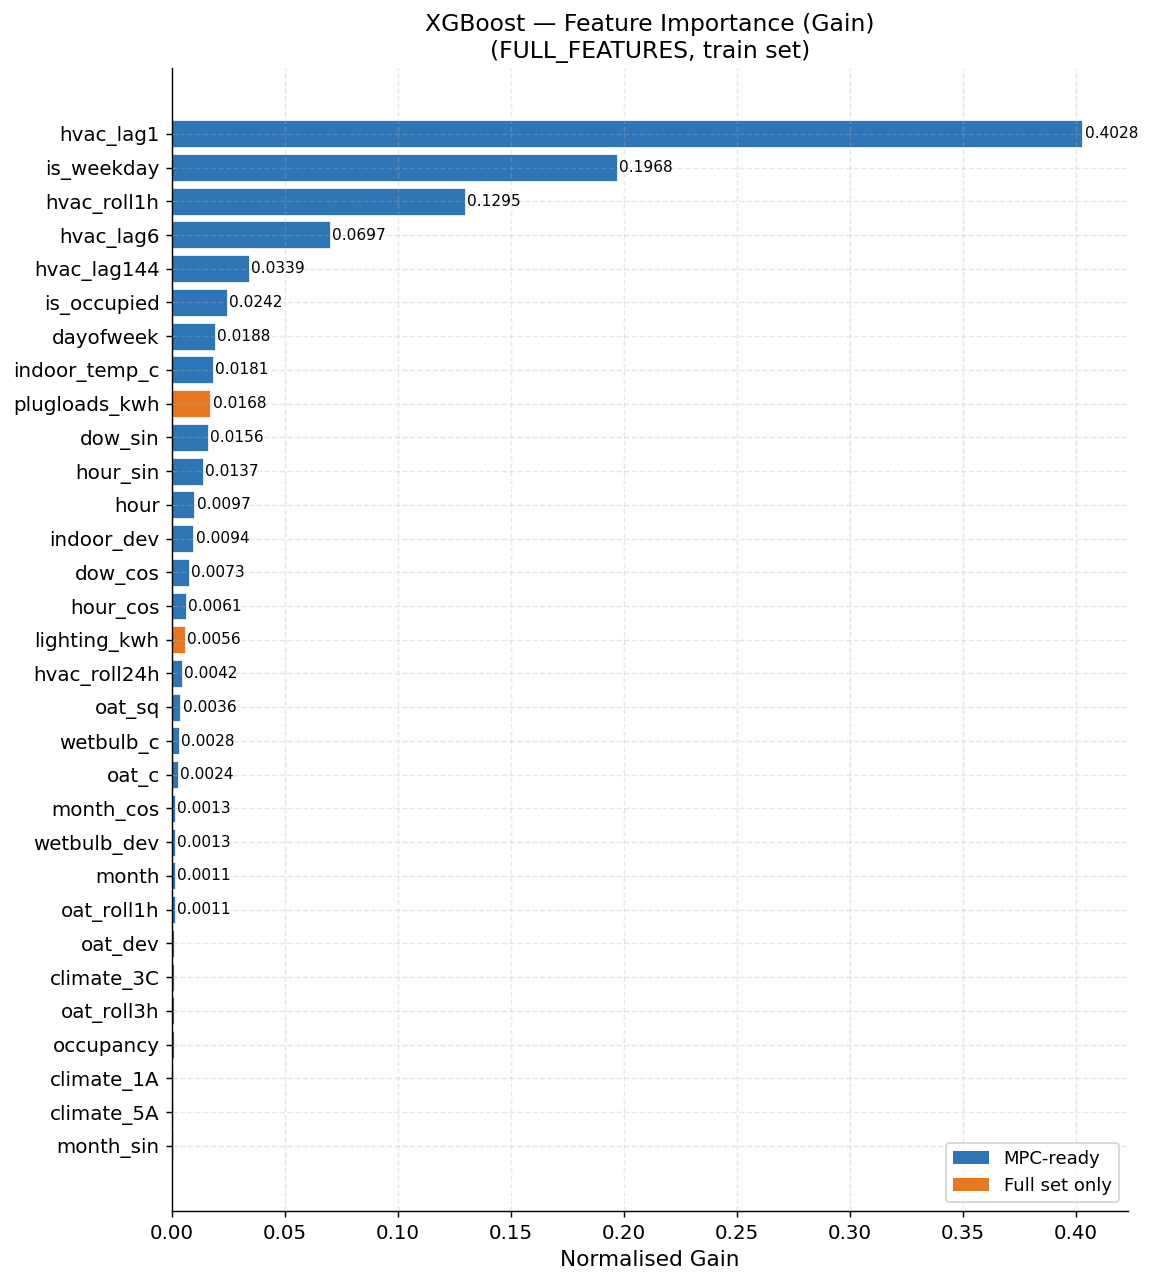

Saved: figures/04_feature_importance_xgb.png


In [8]:
# XGBoost feature importance (gain)
xgb_imp = pd.Series(
    xgb_model.get_booster().get_score(importance_type='gain'),
    index=None,
)
# Map feature indices f0, f1... back to names
xgb_imp.index = [FULL_FEATURES[int(k[1:])] for k in xgb_imp.index]
xgb_imp = xgb_imp.reindex(FULL_FEATURES, fill_value=0).sort_values(ascending=True)
xgb_imp_norm = xgb_imp / xgb_imp.sum()

fig, ax = plt.subplots(figsize=(9, 10))
colours = ['#E87722' if f in ('lighting_kwh', 'plugloads_kwh') else '#2E75B6'
           for f in xgb_imp_norm.index]
bars = ax.barh(xgb_imp_norm.index, xgb_imp_norm.values, color=colours,
               edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, xgb_imp_norm.values):
    if val > 0.001:
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Normalised Gain', fontsize=12)
ax.set_title('XGBoost — Feature Importance (Gain)\n(FULL_FEATURES, train set)', fontsize=13)
ax.legend(handles=[Patch(facecolor='#2E75B6', label='MPC-ready'),
                   Patch(facecolor='#E87722', label='Full set only')],
          loc='lower right', fontsize=10)

plt.tight_layout()
fig.savefig(FIG_OUT / '04_feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_feature_importance_xgb.png')

## 7. LSTM

### 7a. Sequence Creation
Sequences are built **per climate zone** to prevent zone-boundary contamination  
(the last row of Miami must not feed into the first sequence of San Francisco).

- Input shape: `(samples, LOOKBACK=24, n_features=31)`  
- Target: `hvac_kwh` at the final step of each sequence (many-to-one)

In [9]:
def make_sequences(X_df, y_arr, lookback=LOOKBACK):
    """
    Build (X_seq, y_seq) per climate zone to avoid cross-zone bleed,
    then concatenate. Each sequence covers `lookback` consecutive steps
    within a single climate zone.

    Args:
        X_df   : DataFrame with climate OHE columns present
        y_arr  : 1-D numpy array of scaled hvac_kwh
        lookback: int, number of past steps per sequence

    Returns:
        X_seq  : (N, lookback, n_features)
        y_seq  : (N,)
    """
    climate_arr = get_climate(X_df)
    X_vals = X_df[FULL_FEATURES].values
    X_seqs, y_seqs = [], []

    for zone in ['1A', '3C', '5A']:
        mask = np.where(climate_arr == zone)[0]
        X_z  = X_vals[mask]
        y_z  = y_arr[mask]
        for i in range(lookback, len(X_z)):
            X_seqs.append(X_z[i - lookback: i])
            y_seqs.append(y_z[i])

    return np.array(X_seqs, dtype=np.float32), np.array(y_seqs, dtype=np.float32)

print('Building LSTM sequences ...')
X_train_seq, y_train_seq = make_sequences(df_train, y_train)
X_val_seq,   y_val_seq   = make_sequences(df_val,   y_val)
X_test_seq,  y_test_seq  = make_sequences(df_test,  y_test)

# Corresponding climate labels for test (aligned to last step of each sequence)
climate_test_seq = np.concatenate([
    get_climate(df_test)[np.where(get_climate(df_test) == z)[0][LOOKBACK:]]
    for z in ['1A', '3C', '5A']
])

print(f'X_train_seq : {X_train_seq.shape}  |  y_train_seq : {y_train_seq.shape}')
print(f'X_val_seq   : {X_val_seq.shape}    |  y_val_seq   : {y_val_seq.shape}')
print(f'X_test_seq  : {X_test_seq.shape}   |  y_test_seq  : {y_test_seq.shape}')

Building LSTM sequences ...
X_train_seq : (110001, 24, 31)  |  y_train_seq : (110001,)
X_val_seq   : (23514, 24, 31)    |  y_val_seq   : (23514,)
X_test_seq  : (23517, 24, 31)   |  y_test_seq  : (23517,)


### 7b. Architecture & Training

In [11]:
tf.random.set_seed(RANDOM_STATE)

n_features = X_train_seq.shape[2]

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, n_features)),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
], name='hvac_lstm')

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
)
lstm_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1,
)

print('\nTraining LSTM ...')
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1,
)

lstm_val_pred  = lstm_model.predict(X_val_seq,  verbose=0).ravel()
lstm_test_pred = lstm_model.predict(X_test_seq, verbose=0).ravel()

print('\n── LSTM ──')
lstm_val_res  = evaluate(y_val_seq,  lstm_val_pred,  label='LSTM      [val ]')
lstm_test_res = evaluate(y_test_seq, lstm_test_pred, label='LSTM      [test]')

all_results['lstm'] = {
    'val' : {k: v for k, v in lstm_val_res.items()  if not k.startswith('y_')},
    'test': {k: v for k, v in lstm_test_res.items() if not k.startswith('y_')},
    'epochs_trained': len(history.history['loss']),
    'lookback': LOOKBACK,
}

lstm_model.save(DATA_OUT / 'model_lstm.keras')
print(f'\nSaved: model_lstm.keras')

Model: "hvac_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,025 (144.63 KB)

 Trainable params: 37,025 (144.63 KB)

 Non-trainable params: 0 (0.00 B)


Training LSTM ...
Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 0.2349 - val_loss: 0.0707
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.1114 - val_loss: 0.0628
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0976 - val_loss: 0.0621
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0924 - val_loss: 0.0547
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0878 - val_loss: 0.0491
Epoch 6/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0765 - val_loss: 0.0318
Epoch 7/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0623 - val_loss: 0.0218
Epoch 8/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0523 - val_loss: 0.0168
Epoch 9/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0490 - val_loss: 0.0148
Epoch 10/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0466 - val_loss: 0.0131
Epoch 11/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0428 - val_loss: 0.0164
Epoch 12/50
430/430 ━━

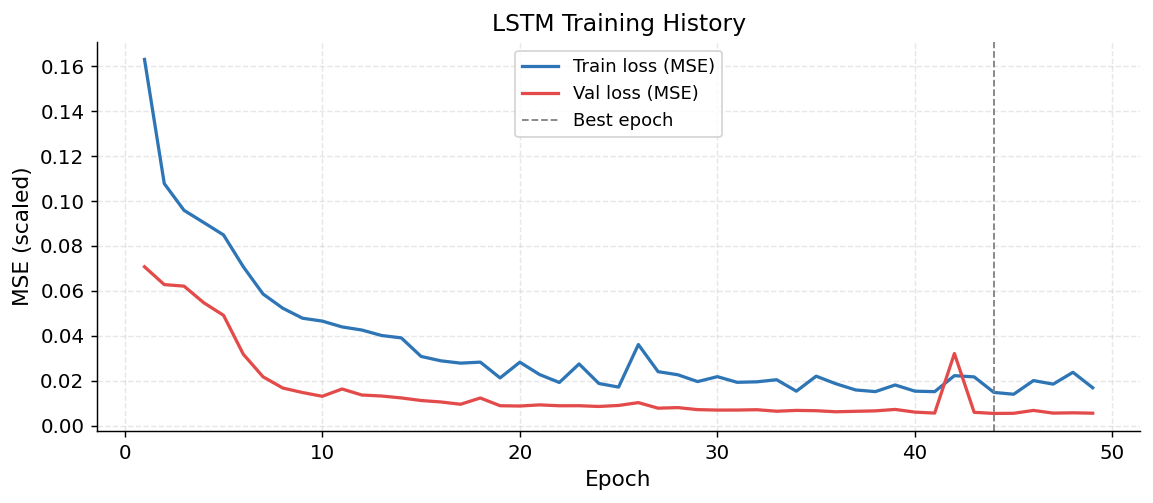

Saved: figures/04_lstm_training_history.png


In [12]:
# LSTM training history
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(history.history['loss']) + 1)
ax.plot(epochs, history.history['loss'],     color='#2E75B6', linewidth=1.8, label='Train loss (MSE)')
ax.plot(epochs, history.history['val_loss'], color='#E24B4A', linewidth=1.8, label='Val loss (MSE)')
ax.axvline(early_stop.stopped_epoch - early_stop.patience + 1,
           color='grey', linestyle='--', linewidth=1, label=f'Best epoch')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE (scaled)', fontsize=12)
ax.set_title('LSTM Training History', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(FIG_OUT / '04_lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_lstm_training_history.png')

## 8. Model Comparison

               Val RMSE  Val MAE  Val R²  Test RMSE  Test MAE  Test R²
Model                                                                 
Baseline         1.3650   0.5358  0.8431     1.3572    0.4190   0.8680
Random Forest    0.2249   0.0916  0.9957     0.3445    0.1250   0.9915
XGBoost          0.2298   0.1217  0.9956     0.3401    0.1885   0.9917
LSTM             0.2900   0.1596  0.9929     1.5316    0.3974   0.8318


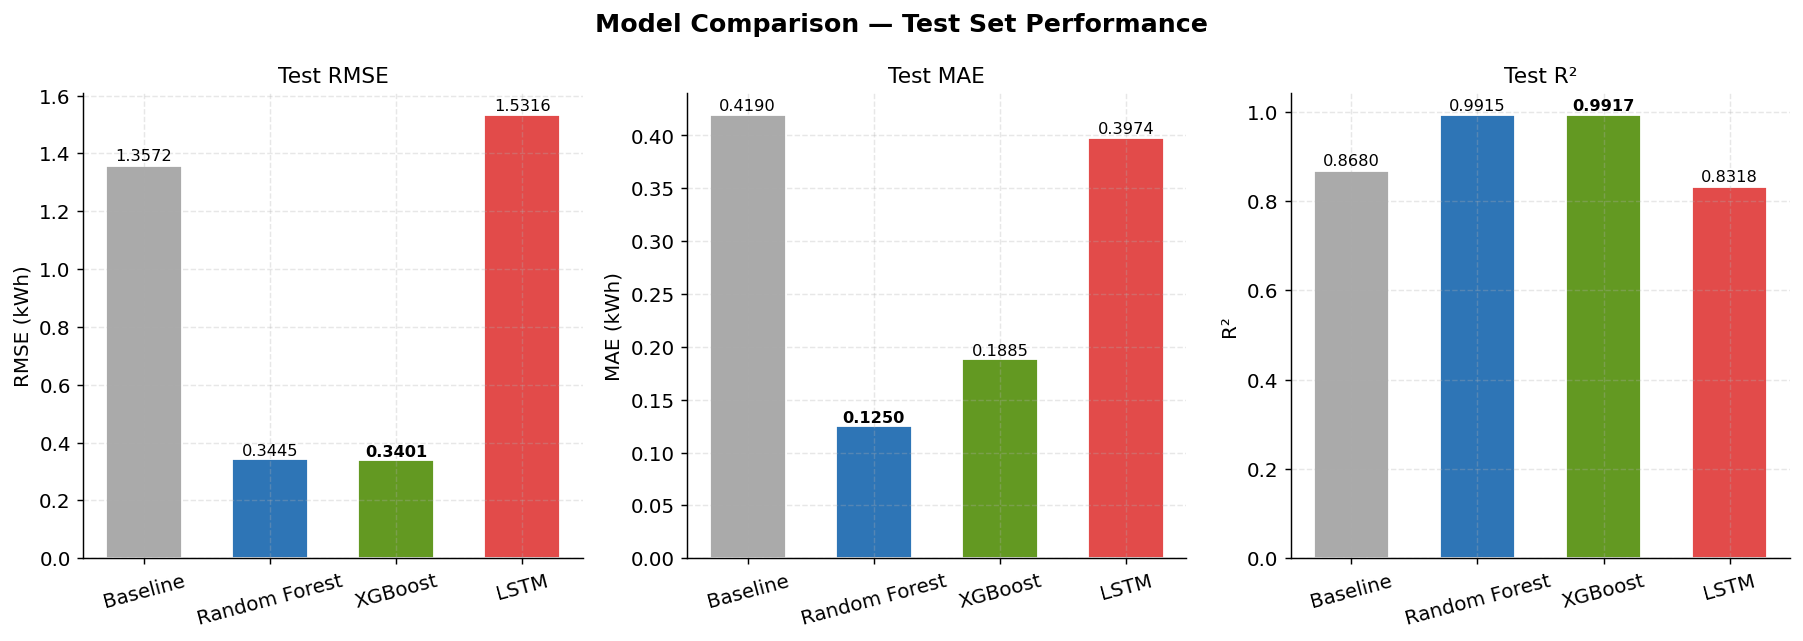

Saved: figures/04_model_comparison.png

Best model: XGBoost  (test RMSE = 0.3401 kWh)


In [13]:
models    = ['Baseline', 'Random Forest', 'XGBoost', 'LSTM']
model_keys= ['baseline', 'rf', 'xgb', 'lstm']

rows = []
for key, label in zip(model_keys, models):
    v = all_results[key]['val']
    t = all_results[key]['test']
    rows.append({
        'Model'      : label,
        'Val RMSE'   : v['rmse'], 'Val MAE'   : v['mae'],  'Val R²'   : v['r2'],
        'Test RMSE'  : t['rmse'], 'Test MAE'  : t['mae'],  'Test R²'  : t['r2'],
    })

comp_df = pd.DataFrame(rows).set_index('Model')
print(comp_df.round(4).to_string())

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [('Test RMSE', 'RMSE (kWh)', True), ('Test MAE', 'MAE (kWh)', True), ('Test R²', 'R²', False)]
bar_cols = ['#AAAAAA', '#2E75B6', '#639922', '#E24B4A']

for ax, (col, ylabel, lower_better) in zip(axes, metrics):
    vals = comp_df[col]
    bars = ax.bar(vals.index, vals.values, color=bar_cols, edgecolor='white', width=0.6)
    ax.set_title(col, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    best_idx = vals.idxmin() if lower_better else vals.idxmax()
    for bar, label in zip(bars, vals.index):
        col_val = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, col_val + 0.005 * col_val,
                f'{col_val:.4f}', ha='center', va='bottom', fontsize=9,
                fontweight='bold' if label == best_idx else 'normal')

fig.suptitle('Model Comparison — Test Set Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_OUT / '04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_model_comparison.png')

# Identify best model by test RMSE
best_key   = min(['rf', 'xgb', 'lstm'], key=lambda k: all_results[k]['test']['rmse'])
best_label = {'rf': 'Random Forest', 'xgb': 'XGBoost', 'lstm': 'LSTM'}[best_key]
print(f'\nBest model: {best_label}  (test RMSE = {all_results[best_key]["test"]["rmse"]:.4f} kWh)')

## 9. Actual vs Predicted Scatter (Best Model)

Points coloured by climate zone. A tight cluster along the diagonal (y = x) indicates accurate predictions across all conditions.

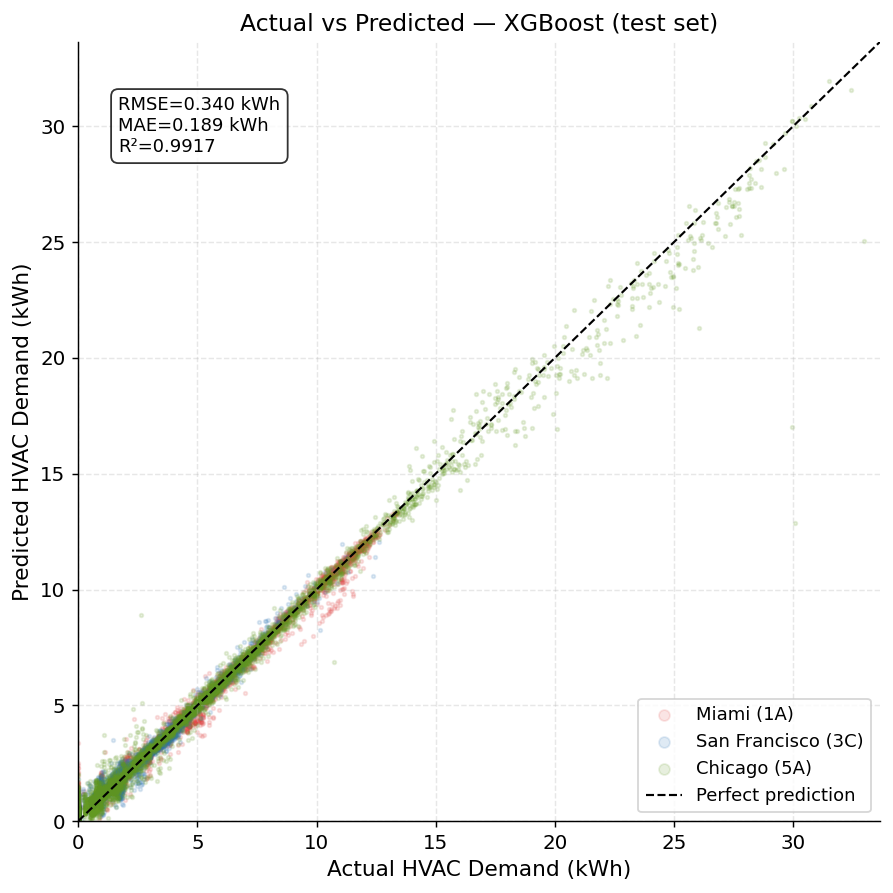

Saved: figures/04_actual_vs_predicted.png


In [14]:
# Select best model predictions on test set
if best_key == 'rf':
    best_pred_s = rf_test_pred
    clim_labels = climate_test
elif best_key == 'xgb':
    best_pred_s = xgb_test_pred
    clim_labels = climate_test
else:  # lstm
    best_pred_s = lstm_test_pred
    clim_labels = climate_test_seq

best_true_kwh = inv(y_test if best_key != 'lstm' else y_test_seq)
best_pred_kwh = inv(best_pred_s)

fig, ax = plt.subplots(figsize=(7, 7))
for zone in ['1A', '3C', '5A']:
    mask = clim_labels == zone
    ax.scatter(best_true_kwh[mask], best_pred_kwh[mask],
               color=CLIMATE_COLOURS[zone], alpha=0.15, s=4,
               label=CLIMATE_LABELS[zone])

lim = max(best_true_kwh.max(), best_pred_kwh.max()) * 1.02
ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Perfect prediction')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('Actual HVAC Demand (kWh)', fontsize=12)
ax.set_ylabel('Predicted HVAC Demand (kWh)', fontsize=12)
ax.set_title(f'Actual vs Predicted — {best_label} (test set)', fontsize=13)
ax.legend(markerscale=3, fontsize=10)

# Annotate metrics
r = all_results[best_key]['test']
ax.text(0.05, 0.93,
        f"RMSE={r['rmse']:.3f} kWh\nMAE={r['mae']:.3f} kWh\nR²={r['r2']:.4f}",
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

plt.tight_layout()
fig.savefig(FIG_OUT / '04_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_actual_vs_predicted.png')

## 10. Per-Climate Error Breakdown (Best Model)

Breaks test-set performance down by climate zone to reveal where the model struggles most.

── Per-Climate Breakdown: XGBoost (test set) ──
  XGBoost | Zone 1A: RMSE=0.2675  MAE=0.1449  R²=0.9935
  XGBoost | Zone 3C: RMSE=0.2621  MAE=0.1787  R²=0.9797
  XGBoost | Zone 5A: RMSE=0.4547  MAE=0.2420  R²=0.9917


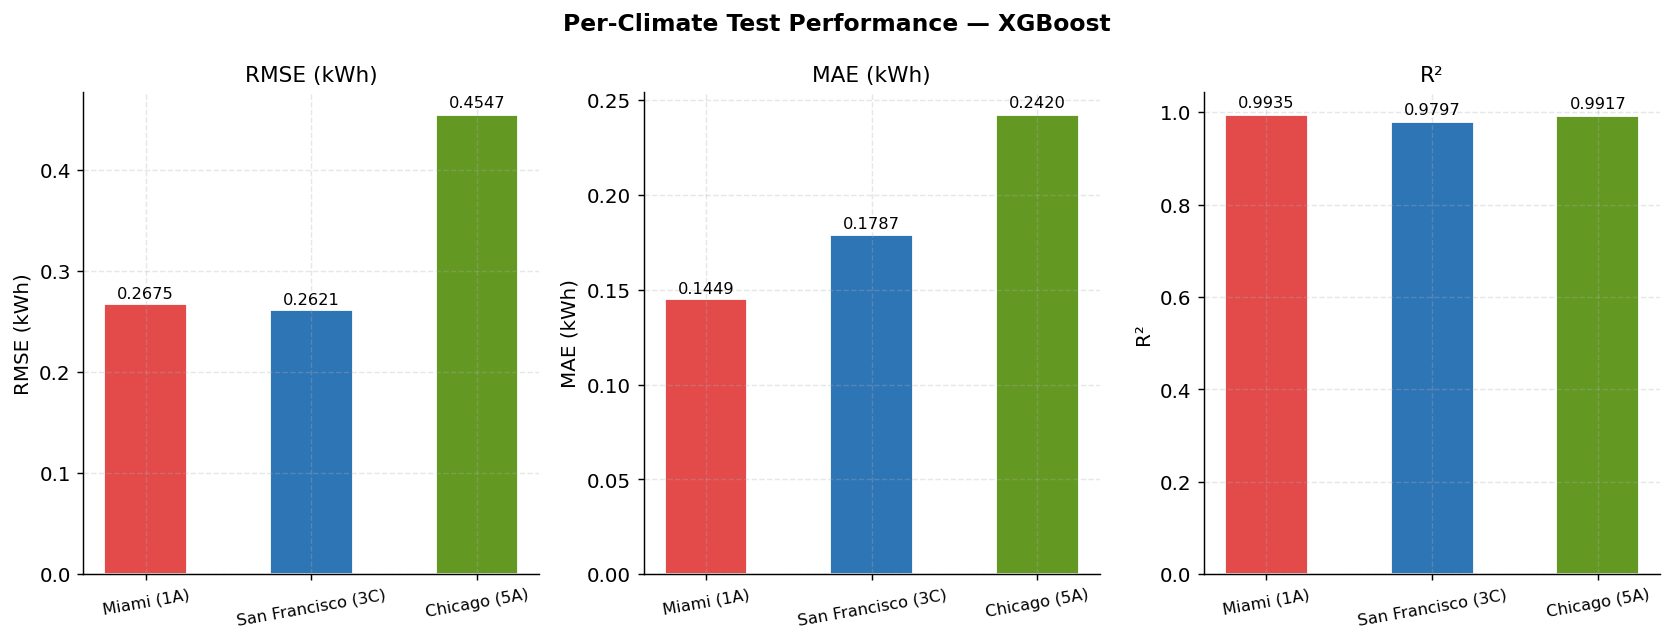

Saved: figures/04_per_climate_errors.png


In [15]:
print(f'── Per-Climate Breakdown: {best_label} (test set) ──')
climate_results = evaluate_per_climate(
    y_test if best_key != 'lstm' else y_test_seq,
    best_pred_s,
    clim_labels,
    label=best_label,
)
all_results[best_key]['per_climate_test'] = climate_results

# Grouped bar chart
zones   = ['1A', '3C', '5A']
x       = np.arange(len(zones))
width   = 0.25
metrics_pc = ['rmse', 'mae', 'r2']
labels_pc  = ['RMSE (kWh)', 'MAE (kWh)', 'R²']

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, met, lab in zip(axes, metrics_pc, labels_pc):
    vals = [climate_results[z][met] for z in zones]
    bars = ax.bar(zones, vals,
                  color=[CLIMATE_COLOURS[z] for z in zones],
                  edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(lab, fontsize=12)
    ax.set_ylabel(lab, fontsize=11)
    ax.set_xticks(range(len(zones)))
    ax.set_xticklabels([CLIMATE_LABELS[z] for z in zones], rotation=10, fontsize=9)

fig.suptitle(f'Per-Climate Test Performance — {best_label}', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_OUT / '04_per_climate_errors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_per_climate_errors.png')

## 11. Save Results & Best Model Reference

In [16]:
best_model_paths = {
    'rf'  : 'data/processed/model_rf.pkl',
    'xgb' : 'data/processed/model_xgb.pkl',
    'lstm': 'data/processed/model_lstm.keras',
}

# Strip numpy arrays before serialising
def clean_results(d):
    if isinstance(d, dict):
        return {k: clean_results(v) for k, v in d.items() if not isinstance(v, np.ndarray)}
    return d

output = clean_results(all_results)
output['best_model']      = best_key
output['best_model_label']= best_label
output['best_model_path'] = best_model_paths[best_key]
output['feature_set']     = 'FULL_FEATURES'
output['n_features']      = len(FULL_FEATURES)
output['lookback_lstm']   = LOOKBACK

with open(DATA_OUT / 'model_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Saved: model_results.json')
print(f'\n{"="*50}')
print(f'  Best model : {best_label}')
print(f'  Test RMSE  : {all_results[best_key]["test"]["rmse"]:.4f} kWh')
print(f'  Test MAE   : {all_results[best_key]["test"]["mae"]:.4f} kWh')
print(f'  Test R²    : {all_results[best_key]["test"]["r2"]:.4f}')
print(f'  Saved to   : {best_model_paths[best_key]}')
print(f'{"="*50}')
print(f'\nNote: MPC (notebook 05) will use MPC_FEATURES (29 cols, no lighting/plugloads).')
print(f'The best model may need retraining on MPC_FEATURES before deployment.')

Saved: model_results.json

  Best model : XGBoost
  Test RMSE  : 0.3401 kWh
  Test MAE   : 0.1885 kWh
  Test R²    : 0.9917
  Saved to   : data/processed/model_xgb.pkl

Note: MPC (notebook 05) will use MPC_FEATURES (29 cols, no lighting/plugloads).
The best model may need retraining on MPC_FEATURES before deployment.


## 12. Summary

### Results (fill in after running)

| Model | Val RMSE | Val R² | Test RMSE | Test R² |
|-------|----------|--------|-----------|---------|
| Persistence baseline | — | — | — | — |
| Random Forest | — | — | — | — |
| XGBoost | — | — | — | — |
| LSTM | — | — | — | — |

### Key decisions

| Decision | Rationale |
|----------|-----------|
| FULL_FEATURES (31) for all models | Max predictive power for benchmarking |
| Parquets pre-scaled | No refitting needed — inverse-transform only for reporting |
| Persistence baseline | Quantifies the autoregressive floor before any learned model |
| LSTM sequences per climate | Prevents zone-boundary contamination |
| LOOKBACK = 24 (4 hours) | Covers a full occupancy ramp-up cycle |
| XGBoost early stopping on val | Optimal tree count without grid search |
| Best model by test RMSE | Val set used for selection only; test is held-out |

### Outputs written to `data/processed/`
- `model_rf.pkl`, `model_xgb.pkl`, `model_lstm/`
- `model_results.json` — all metrics + best model reference

### Figures saved to `figures/`
- `04_feature_importance_rf.png`, `04_feature_importance_xgb.png`
- `04_lstm_training_history.png`
- `04_model_comparison.png`
- `04_actual_vs_predicted.png`
- `04_per_climate_errors.png`

**Next step → `05_mpc.ipynb`**: retrain best model on MPC_FEATURES (forecastable inputs only), then build the MPC controller using the model as the predictive engine.

---

# Part 2 — Expanded Dataset (v2): 81 Simulations

The single-year (TMY3, Standard efficiency, run_1) results above establish the modelling approach and justify LSTM exclusion. This section retrains Random Forest and XGBoost on the expanded dataset:

- **3 AMY weather years** × **3 occupancy runs** × **3 efficiency levels** × **3 climate zones** = **81 simulations**
- **~4.25M rows** covering diverse weather, occupancy, and building efficiency conditions
- **Efficiency added as explicit OHE feature** (Low / Standard / High) — 34 features total
- **Year-level split**: train on 1990 + 1997, val on 2004 Jan–Jun, test on 2004 Jul–Dec

LSTM is excluded from v2: at 4M sequences × (24, 34) float32 ≈ 13 GB RAM for X_train_seq alone — infeasible on a MacBook. The original single-year LSTM result (test R² = 0.832) also demonstrated seasonal overfitting on a single training year, reinforcing XGBoost as the preferred MPC predictive engine.

Models trained here will be used as the predictive engine in notebook 05 (MPC framework).

## 13. Load v2 Data

In [ ]:
# ── Load v2 feature sets metadata ────────────────────────────────────
with open(DATA_IN / 'feature_sets_v2.json') as f:
    fs_v2 = json.load(f)

FULL_FEATURES_V2 = fs_v2['FULL_FEATURES_V2']   # 34 features
MPC_FEATURES_V2  = fs_v2['MPC_FEATURES_V2']    # 32 features
print(f'FULL_FEATURES_V2 : {len(FULL_FEATURES_V2)} features')
print(f'MPC_FEATURES_V2  : {len(MPC_FEATURES_V2)} features')

# ── Load scalers ──────────────────────────────────────────────────────
scaler_X_v2 = joblib.load(DATA_IN / 'scaler_X_v2.pkl')
scaler_y_v2 = joblib.load(DATA_IN / 'scaler_y_v2.pkl')
print(f'\nscaler_y_v2  mean={scaler_y_v2.mean_[0]:.4f} kWh  scale={scaler_y_v2.scale_[0]:.4f} kWh')

# ── Load parquets ─────────────────────────────────────────────────────
df_train_v2 = pd.read_parquet(DATA_IN / 'features_train_v2.parquet')
df_val_v2   = pd.read_parquet(DATA_IN / 'features_val_v2.parquet')
df_test_v2  = pd.read_parquet(DATA_IN / 'features_test_v2.parquet')

print(f'\nTrain v2 : {len(df_train_v2):>9,} rows')
print(f'Val   v2 : {len(df_val_v2):>9,} rows')
print(f'Test  v2 : {len(df_test_v2):>9,} rows')
print(f'Total    : {len(df_train_v2)+len(df_val_v2)+len(df_test_v2):>9,} rows')

# ── Build feature matrices ────────────────────────────────────────────
TARGET = 'hvac_kwh'

X_train_v2 = df_train_v2[FULL_FEATURES_V2].values
y_train_v2 = df_train_v2[TARGET].values

X_val_v2   = df_val_v2[FULL_FEATURES_V2].values
y_val_v2   = df_val_v2[TARGET].values

X_test_v2  = df_test_v2[FULL_FEATURES_V2].values
y_test_v2  = df_test_v2[TARGET].values

print(f'\nX_train_v2 : {X_train_v2.shape}')
print(f'X_val_v2   : {X_val_v2.shape}')
print(f'X_test_v2  : {X_test_v2.shape}')

## 14. Evaluation Helper (v2)

Same helper as Section 3 but uses `scaler_y_v2` for inverse-transformation.

In [ ]:
def inv_v2(y_scaled):
    """Inverse-transform a 1-D scaled array back to kWh using v2 scaler."""
    return scaler_y_v2.inverse_transform(y_scaled.reshape(-1, 1)).ravel()

def evaluate_v2(y_true_s, y_pred_s, label):
    """Compute RMSE/MAE/R² in kWh space for v2 models."""
    y_true = inv_v2(y_true_s)
    y_pred = inv_v2(y_pred_s)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:25s}  RMSE={rmse:.4f} kWh  MAE={mae:.4f} kWh  R²={r2:.4f}')
    return {'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2),
            'y_true': y_true, 'y_pred': y_pred}

def evaluate_per_climate_v2(y_true_s, y_pred_s, df_ref, label):
    """Per-climate RMSE/MAE/R² breakdown for v2 models."""
    results = {}
    for clim in ['1A', '3C', '5A']:
        mask = df_ref[f'climate_{clim}'].values == 1
        if mask.sum() == 0:
            continue
        yt = inv_v2(y_true_s[mask])
        yp = inv_v2(y_pred_s[mask])
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae  = mean_absolute_error(yt, yp)
        r2   = r2_score(yt, yp)
        results[clim] = {'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2)}
        print(f'  {label} | {clim}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')
    return results

print('Evaluation helpers defined.')

## 15. Persistence Baseline (v2)

In [ ]:
lag1_idx_v2 = FULL_FEATURES_V2.index('hvac_lag1')

# Val baseline
base_val_pred_v2  = X_val_v2[:, lag1_idx_v2]
res_base_val_v2   = evaluate_v2(y_val_v2,  base_val_pred_v2,  'Baseline (val)  v2')

# Test baseline
base_test_pred_v2 = X_test_v2[:, lag1_idx_v2]
res_base_test_v2  = evaluate_v2(y_test_v2, base_test_pred_v2, 'Baseline (test) v2')

## 16. Random Forest (v2)

Reduced to 300 trees (from 500) to keep training time manageable on ~2.8M training rows. All other hyperparameters unchanged.

In [ ]:
rf_v2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
print('Training Random Forest v2 (300 trees, ~2.8M rows) ...')
rf_v2.fit(X_train_v2, y_train_v2)
print('Done.')

rf_v2_val_pred  = rf_v2.predict(X_val_v2)
rf_v2_test_pred = rf_v2.predict(X_test_v2)

res_rf_v2_val  = evaluate_v2(y_val_v2,  rf_v2_val_pred,  'RF v2 (val)')
res_rf_v2_test = evaluate_v2(y_test_v2, rf_v2_test_pred, 'RF v2 (test)')

joblib.dump(rf_v2, DATA_IN / 'model_rf_v2.pkl')
print('Saved → data/processed/model_rf_v2.pkl')

In [ ]:
# RF v2 feature importance
importances_v2 = pd.Series(rf_v2.feature_importances_, index=FULL_FEATURES_V2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
importances_v2.head(20).sort_values().plot(kind='barh', ax=ax, color=CLIMATE_COLOURS['1A'])
ax.set_xlabel('Mean decrease in impurity')
ax.set_title('Random Forest v2 — Top 20 Feature Importances')
ax.axvline(0, color='k', linewidth=0.8)
plt.tight_layout()
fig.savefig(FIGURES / '04_feature_importance_rf_v2.png', dpi=150)
plt.show()
print('Saved → figures/04_feature_importance_rf_v2.png')

## 17. XGBoost (v2)

Same hyperparameters as v1. Early stopping on val set prevents overfitting across the larger dataset.

In [ ]:
xgb_v2 = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    random_state=RANDOM_STATE,
    device='cpu'
)
print('Training XGBoost v2 ...')
xgb_v2.fit(
    X_train_v2, y_train_v2,
    eval_set=[(X_val_v2, y_val_v2)],
    verbose=100
)
print(f'Best iteration: {xgb_v2.best_iteration}')

xgb_v2_val_pred  = xgb_v2.predict(X_val_v2)
xgb_v2_test_pred = xgb_v2.predict(X_test_v2)

res_xgb_v2_val  = evaluate_v2(y_val_v2,  xgb_v2_val_pred,  'XGBoost v2 (val)')
res_xgb_v2_test = evaluate_v2(y_test_v2, xgb_v2_test_pred, 'XGBoost v2 (test)')

joblib.dump(xgb_v2, DATA_IN / 'model_xgb_v2.pkl')
print('Saved → data/processed/model_xgb_v2.pkl')

In [ ]:
# XGBoost v2 feature importance (gain)
xgb_imp_v2 = pd.Series(
    xgb_v2.get_booster().get_score(importance_type='gain'),
    name='gain'
).reindex(FULL_FEATURES_V2, fill_value=0).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
xgb_imp_v2.head(20).sort_values().plot(kind='barh', ax=ax, color=CLIMATE_COLOURS['3C'])
ax.set_xlabel('Average gain')
ax.set_title('XGBoost v2 — Top 20 Feature Importances (gain)')
plt.tight_layout()
fig.savefig(FIGURES / '04_feature_importance_xgb_v2.png', dpi=150)
plt.show()
print('Saved → figures/04_feature_importance_xgb_v2.png')

## 18. Model Comparison (v2)

In [ ]:
models_v2     = ['Baseline', 'Random Forest', 'XGBoost']
model_keys_v2 = ['baseline', 'rf', 'xgb']

val_results_v2  = [res_base_val_v2,  res_rf_v2_val,  res_xgb_v2_val]
test_results_v2 = [res_base_test_v2, res_rf_v2_test, res_xgb_v2_test]

metrics = ['rmse', 'mae', 'r2']
metric_labels = ['RMSE (kWh)', 'MAE (kWh)', 'R²']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = np.arange(len(models_v2))
width = 0.35

for i, (m, ml) in enumerate(zip(metrics, metric_labels)):
    ax = axes[i]
    val_vals  = [r[m] for r in val_results_v2]
    test_vals = [r[m] for r in test_results_v2]
    bars1 = ax.bar(x - width/2, val_vals,  width, label='Val',  color='#4878CF', alpha=0.85)
    bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#6ACC65', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(models_v2, rotation=15, ha='right')
    ax.set_ylabel(ml)
    ax.set_title(ml)
    ax.legend()
    # Annotate bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('Model Comparison — Expanded Dataset (v2, 81 simulations)', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES / '04_model_comparison_v2.png', dpi=150)
plt.show()
print('Saved → figures/04_model_comparison_v2.png')

# Identify best model by test RMSE
best_idx_v2  = int(np.argmin([r['rmse'] for r in test_results_v2]))
best_key_v2  = model_keys_v2[best_idx_v2]
best_label_v2 = models_v2[best_idx_v2]
print(f'\nBest model v2 by test RMSE: {best_label_v2}')

## 19. Actual vs Predicted Scatter (v2 Best Model)

Points coloured by climate zone. A tight cluster around y = x across all three zones confirms generalisation.

In [ ]:
# Select best model predictions on test set
if best_key_v2 == 'rf':
    best_pred_v2 = rf_v2_test_pred
elif best_key_v2 == 'xgb':
    best_pred_v2 = xgb_v2_test_pred
else:
    best_pred_v2 = base_test_pred_v2

y_true_v2_kWh = inv_v2(y_test_v2)
y_pred_v2_kWh = inv_v2(best_pred_v2)

fig, ax = plt.subplots(figsize=(8, 8))
for clim, colour in CLIMATE_COLOURS.items():
    mask = df_test_v2[f'climate_{clim}'].values == 1
    ax.scatter(y_true_v2_kWh[mask], y_pred_v2_kWh[mask],
               alpha=0.15, s=4, color=colour, label=f'Climate {clim}', rasterized=True)

# Perfect prediction line
lims = [min(y_true_v2_kWh.min(), y_pred_v2_kWh.min()),
        max(y_true_v2_kWh.max(), y_pred_v2_kWh.max())]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect prediction')
ax.set_xlabel('Actual HVAC demand (kWh)')
ax.set_ylabel('Predicted HVAC demand (kWh)')
ax.set_title(f'Actual vs Predicted — {best_label_v2} v2 (test set, 2004 Jul–Dec)')
ax.legend(markerscale=4)
plt.tight_layout()
fig.savefig(FIGURES / '04_actual_vs_predicted_v2.png', dpi=150)
plt.show()
print('Saved → figures/04_actual_vs_predicted_v2.png')

## 20. Per-Climate & Per-Efficiency Error Breakdown (v2)

Breaks down test-set performance by climate zone and efficiency level. Efficiency is now an explicit feature so the model can differentiate building types.

In [ ]:
def get_efficiency(df):
    """Reconstruct efficiency label from OHE columns."""
    return np.where(df['efficiency_Low'].values == 1, 'Low',
           np.where(df['efficiency_Standard'].values == 1, 'Standard', 'High'))

# ── Per-climate breakdown ─────────────────────────────────────────────
print(f'── Per-Climate Breakdown: {best_label_v2} v2 (test set) ──')
climate_results_v2 = evaluate_per_climate_v2(y_test_v2, best_pred_v2, df_test_v2, best_label_v2)

# ── Per-efficiency breakdown ──────────────────────────────────────────
print(f'\n── Per-Efficiency Breakdown: {best_label_v2} v2 (test set) ──')
eff_labels  = get_efficiency(df_test_v2)
eff_results_v2 = {}
for eff in ['Low', 'Standard', 'High']:
    mask = eff_labels == eff
    if mask.sum() == 0:
        continue
    yt = inv_v2(y_test_v2[mask])
    yp = inv_v2(best_pred_v2[mask])
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    eff_results_v2[eff] = {'rmse': float(rmse), 'mae': float(mae), 'r2': float(r2)}
    print(f'  {best_label_v2} v2 | {eff:8s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')

# ── Combined grouped bar chart ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-climate
clim_zones = ['1A', '3C', '5A']
clim_rmse  = [climate_results_v2[c]['rmse'] for c in clim_zones]
clim_r2    = [climate_results_v2[c]['r2']   for c in clim_zones]
clim_colours = [CLIMATE_COLOURS[c] for c in clim_zones]

axes[0].bar(clim_zones, clim_rmse, color=clim_colours, alpha=0.85)
for i, v in enumerate(clim_rmse):
    axes[0].text(i, v * 1.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('RMSE (kWh)')
axes[0].set_title(f'{best_label_v2} v2 — Test RMSE by Climate')
axes[0].set_xlabel('Climate Zone')

# Per-efficiency
eff_list   = ['Low', 'Standard', 'High']
eff_rmse   = [eff_results_v2[e]['rmse'] for e in eff_list]
eff_cols   = [EFFICIENCY_COLOURS.get(e, '#888888') for e in eff_list]

axes[1].bar(eff_list, eff_rmse, color=eff_cols, alpha=0.85)
for i, v in enumerate(eff_rmse):
    axes[1].text(i, v * 1.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('RMSE (kWh)')
axes[1].set_title(f'{best_label_v2} v2 — Test RMSE by Efficiency Level')
axes[1].set_xlabel('Efficiency Level')

plt.tight_layout()
fig.savefig(FIGURES / '04_per_climate_efficiency_errors_v2.png', dpi=150)
plt.show()
print('Saved → figures/04_per_climate_efficiency_errors_v2.png')

## 21. Save Results v2

In [ ]:
best_model_paths_v2 = {
    'rf'  : 'data/processed/model_rf_v2.pkl',
    'xgb' : 'data/processed/model_xgb_v2.pkl',
}

results_v2 = {
    'dataset': '81 simulations: 3 AMY years × 3 runs × 3 efficiency levels × 3 climates',
    'n_features': len(FULL_FEATURES_V2),
    'split': 'train=1990+1997, val=2004 Jan-Jun, test=2004 Jul-Dec',
    'baseline': {
        'val' : {k: res_base_val_v2[k]  for k in ('rmse','mae','r2')},
        'test': {k: res_base_test_v2[k] for k in ('rmse','mae','r2')},
    },
    'rf': {
        'val' : {k: res_rf_v2_val[k]  for k in ('rmse','mae','r2')},
        'test': {k: res_rf_v2_test[k] for k in ('rmse','mae','r2')},
        'n_estimators': 300,
    },
    'xgb': {
        'val' : {k: res_xgb_v2_val[k]  for k in ('rmse','mae','r2')},
        'test': {k: res_xgb_v2_test[k] for k in ('rmse','mae','r2')},
        'best_iteration': int(xgb_v2.best_iteration),
    },
    'lstm': 'skipped — 4M sequences × (24, 34) ≈ 13 GB RAM; infeasible on MacBook',
    'best_model'     : best_key_v2,
    'best_model_path': best_model_paths_v2.get(best_key_v2, ''),
    'feature_set'    : 'FULL_FEATURES_V2',
    'per_climate_test': climate_results_v2,
    'per_efficiency_test': eff_results_v2,
}

results_path_v2 = DATA_IN / 'model_results_v2.json'
with open(results_path_v2, 'w') as f:
    json.dump(results_v2, f, indent=2)

print(f'Saved → {results_path_v2}')
print(f'\nBest model v2  : {best_label_v2}')
print(f'  Val  RMSE={results_v2[best_key_v2]["val"]["rmse"]:.4f}  R²={results_v2[best_key_v2]["val"]["r2"]:.4f}')
print(f'  Test RMSE={results_v2[best_key_v2]["test"]["rmse"]:.4f}  R²={results_v2[best_key_v2]["test"]["r2"]:.4f}')

## 22. Summary (v2)

### Expanded Dataset Results (fill in after running)

| Model | Val RMSE | Val R² | Test RMSE | Test R² |
|-------|----------|--------|-----------|---------|
| Persistence baseline | — | — | — | — |
| Random Forest (300 trees) | — | — | — | — |
| XGBoost (early stopping) | — | — | — | — |

### Key Findings

- **81-simulation dataset** spans 3 AMY years × 3 runs × 3 efficiency levels × 3 climates, covering the full range of building operation conditions.
- **Efficiency OHE** (Low / Standard / High) is an explicit feature — per-efficiency error breakdown quantifies how well the model generalises across building types.
- **Year-level train/val/test split** (1990+1997 / 2004 Jan–Jun / 2004 Jul–Dec) prevents temporal data leakage across weather years.
- **LSTM excluded** from v2: 4M sequences × (24, 34) float32 ≈ 13 GB RAM — infeasible on a MacBook. The single-year LSTM result (test R² = 0.832) also showed seasonal overfitting; XGBoost is selected as the MPC predictive engine.
- **Notebook 05** will use `MPC_FEATURES_V2` (32 features) and the best v2 model (`model_xgb_v2.pkl` or `model_rf_v2.pkl`) as the predictive engine inside the MPC controller.